# How to Save and Export Cartogram Results

Once you have a cartogram you're happy with, you'll want to either save it for later or export it to a GIS format. This guide shows both options:

1. **Save and reload** — preserves the full `Cartogram` object (errors, history, options)
2. **Export to GeoDataFrame** — converts morphed geometries to a table you can plot or save to file

In [1]:
import carto_flow.data as examples
import carto_flow.flow_cartogram as flow

In [2]:
gdf = examples.load_us_census(population=True)
cartogram = flow.morph_gdf(gdf, "Population")

Morph geometries:  22%|████▍               | 112/500 [00:03<00:13, 29.58it/s, max=1.2%, mean=0.2% - converged]


## Option 1: Save and reload the Cartogram object

`cartogram.save()` writes the result to a JSON file that can be reloaded with `Cartogram.load()`. This preserves everything: morphed geometries, error history, convergence data, and the options used.

In [3]:
cartogram.save("my_cartogram.json")

# Later, in another session:
loaded = flow.Cartogram.load("my_cartogram.json")
print("Status after reload:", loaded.status)
print("Mean error:", loaded.get_errors().mean_error_pct, "%")

Status after reload: converged
Mean error: 0.2327604968295871 %


## Option 2: Export to GeoDataFrame

`to_geodataframe()` returns the morphed geometries as a GeoDataFrame with the original columns plus error and density columns. From there, you can write to any format GeoPandas supports.

In [4]:
result_gdf = cartogram.to_geodataframe()
print(result_gdf.columns.tolist())
result_gdf.head(3)

['STATE', 'State Name', 'Population', 'geometry', 'State Abbreviation', 'Population (Millions)', 'Population Density', '_morph_error_pct', '_morph_density']


,STATE,State Name,Population,geometry,State Abbreviation,Population (Millions),Population Density,_morph_error_pct,_morph_density
0,42,Pennsylvania,12794885,"POLYGON ((888717.564 266417.625, 888385.153 26...",PA,12.794885,109.040911,-0.133324,0.000042
1,06,California,39346023,"MULTIPOLYGON (((-1880692.408 -525043.318, -188...",CA,39.346023,96.008122,-0.026952,0.000042
2,54,West Virginia,1807426,"POLYGON ((784468.649 -222213.647, 784493.514 -...",WV,1.807426,28.801063,-0.062484,0.000042


In [5]:
# Write to GeoPackage for use in QGIS, ArcGIS, etc.
result_gdf.to_file("cartogram.gpkg", driver="GPKG")

# Or to GeoJSON for web maps
result_gdf.to_file("cartogram.geojson", driver="GeoJSON")

## Quick check: plot the reloaded result

Verify the save/load round-trip by plotting the reloaded cartogram.

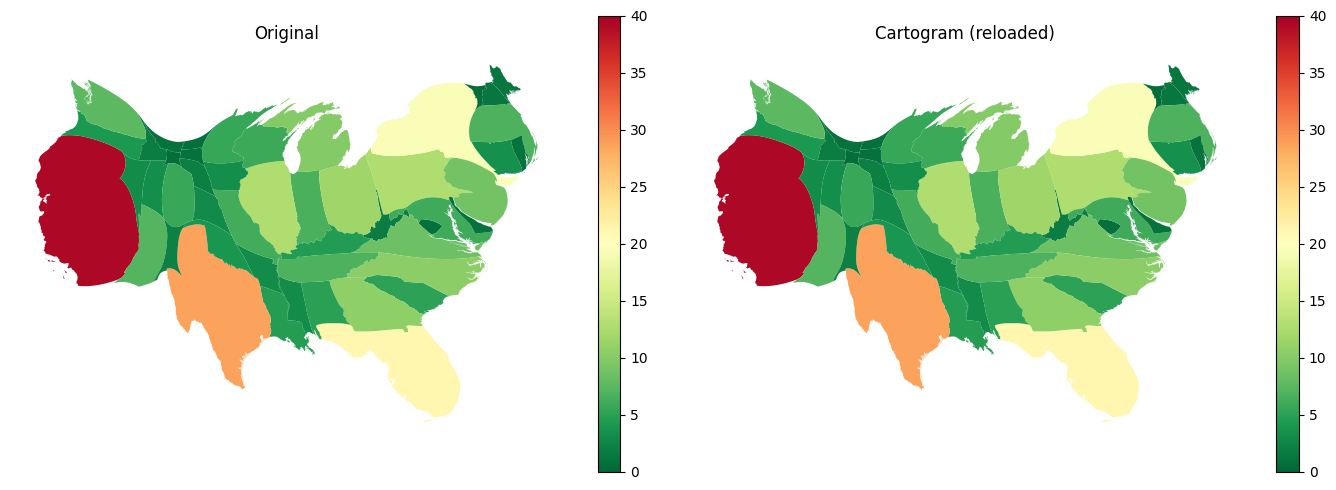

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cartogram.plot("Population (Millions)", ax=axes[0], cmap="RdYlGn_r", legend=True, vmin=0, vmax=40)
axes[0].set(title="Original")
axes[0].axis("off")

loaded.to_geodataframe().plot("Population (Millions)", ax=axes[1], cmap="RdYlGn_r", legend=True, vmin=0, vmax=40)
axes[1].set(title="Cartogram (reloaded)")
axes[1].axis("off")

plt.tight_layout();